<a href="https://colab.research.google.com/github/janosv246/MPA-MLF-Project/blob/main/MPA_MLF_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MPA-MLF Project**  

Vít Janoš, Kryštof Havrda

### 0. Import libraries

In [21]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from keras.optimizers import Adam
from keras.optimizers import SGD

#### 1.1 Set paths

In [22]:
TRAIN_DIR = '/content/x_train'
TEST_DIR = '/content/x_test'
TRAIN_CSV = '/content/y_train_v2.csv'
SAMPLE_SUBMISSION_CSV = '/content/y_test_submission_example_v2.csv'

#### 1.2 Load labels and image paths

In [23]:
def numeric_file_key(path_obj: Path):
    stem = path_obj.stem
    digits = ''.join(ch for ch in stem if ch.isdigit())
    return int(digits) if digits else stem


def find_id_and_label_columns(df: pd.DataFrame):
    lower_cols = [str(c).strip().lower() for c in df.columns]

    id_candidates = ['id', 'image', 'image_id', 'img_id', 'index']
    label_candidates = ['label', 'labels', 'class', 'target', 'y']

    id_col = None
    label_col = None

    for original, lower in zip(df.columns, lower_cols):
        if lower in id_candidates and id_col is None:
            id_col = original
        if lower in label_candidates and label_col is None:
            label_col = original

    if df.shape[1] == 1:
        label_col = df.columns[0]
        id_col = None
    elif df.shape[1] >= 2:
        if id_col is None:
            id_col = df.columns[0]
        if label_col is None:
            label_col = df.columns[1]

    return id_col, label_col


train_df = pd.read_csv(TRAIN_CSV)
train_id_col, train_label_col = find_id_and_label_columns(train_df)

train_image_paths = sorted(Path(TRAIN_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of training images: {len(train_image_paths)}')
print('Train CSV columns:', list(train_df.columns))

if train_id_col is None:
    train_labels_df = pd.DataFrame({
        'id': np.arange(1, len(train_df) + 1),
        'label': train_df[train_label_col].to_numpy()
    })
else:
    train_labels_df = train_df[[train_id_col, train_label_col]].copy()
    train_labels_df.columns = ['id', 'label']

train_labels_df = train_labels_df.sort_values('id').reset_index(drop=True)
train_image_ids = np.array([numeric_file_key(p) for p in train_image_paths])

print(train_labels_df.head())

Number of training images: 1352
Train CSV columns: ['id', 'target']
   id  label
0   0      0
1   1      1
2   2      0
3   3      2
4   4      2


#### 1.3 Show a few images

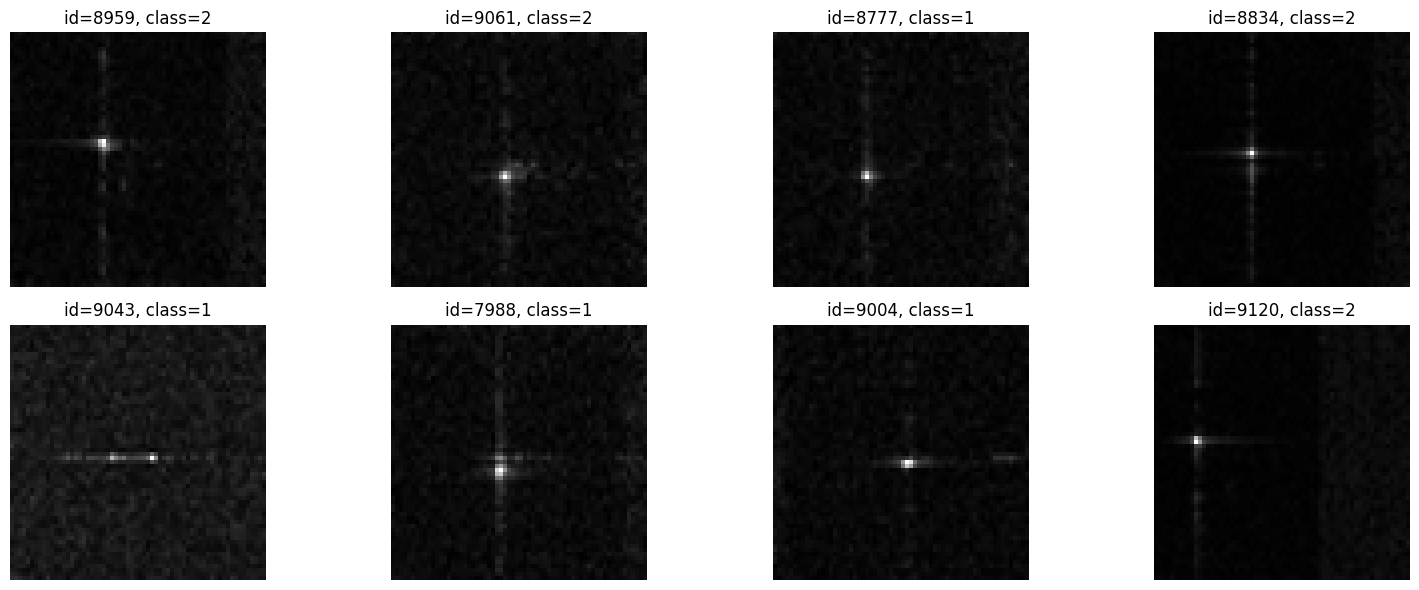

In [24]:
def load_grayscale_image(image_path, target_size=(64, 64)):
    image = Image.open(image_path).convert('L')
    image = image.resize(target_size)
    image = np.array(image, dtype=np.float32) / 255.0
    return image


def display_random_images(image_paths, labels_df, count=8, target_size=(64, 64)):
    selected_idx = np.random.choice(len(image_paths), size=count, replace=False)

    plt.figure(figsize=(16, 6))
    for i, idx in enumerate(selected_idx, 1):
        img_path = image_paths[idx]
        img_id = numeric_file_key(img_path)
        label_row = labels_df.loc[labels_df['id'] == img_id, 'label']
        label = int(label_row.iloc[0]) if len(label_row) > 0 else -1

        img = load_grayscale_image(img_path, target_size=target_size)

        plt.subplot(2, 4, i)
        plt.imshow(img, cmap='gray')
        plt.title(f'id={img_id}, class={label}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


display_random_images(train_image_paths, train_labels_df)

#### 1.4 Load and preprocess the dataset

In [25]:
def build_dataset(image_paths, labels_df=None, target_size=(64, 64)):
    X = []
    y = []
    ids = []

    label_map = None
    if labels_df is not None:
        label_map = dict(zip(labels_df['id'].astype(int), labels_df['label'].astype(int)))

    for img_path in image_paths:
        img_id = int(numeric_file_key(img_path))

        # Skip image if no label exists in label_map
        if label_map is not None and img_id not in label_map:
            continue

        img = load_grayscale_image(img_path, target_size=target_size)
        X.append(img)
        ids.append(img_id)

        if label_map is not None:
            y.append(label_map[img_id])

    X = np.array(X, dtype=np.float32)
    X = X.reshape(-1, target_size[0], target_size[1], 1)
    ids = np.array(ids)

    if label_map is not None:
        y = np.array(y, dtype=np.int32)
        return X, y, ids

    return X, ids


IMG_SIZE = (64, 64)
NUM_CLASSES = 4

X, y, train_ids = build_dataset(train_image_paths, train_labels_df, target_size=IMG_SIZE)
y_cat = to_categorical(y, NUM_CLASSES)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')
print('Classes:', np.unique(y))

X shape: (1351, 64, 64, 1)
y shape: (1351,)
X_train shape: (1080, 64, 64, 1)
X_val shape: (271, 64, 64, 1)
y_train shape: (1080, 4)
y_val shape: (271, 4)
Classes: [0 1 2 3]


### 2. Build the model

#### 2.1 Define the model structure

In [26]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,092 (6.20 MB)

 Trainable params: 1,625,092 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

In [27]:
epochs = 30
batch_size = 32

model.compile(optimizer=SGD(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.3204 - loss: 1.3667 - val_accuracy: 0.3247 - val_loss: 1.3632
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.3444 - loss: 1.3494 - val_accuracy: 0.3616 - val_loss: 1.3492
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.3731 - loss: 1.3318 - val_accuracy: 0.4096 - val_loss: 1.3354
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.3713 - loss: 1.3154 - val_accuracy: 0.4133 - val_loss: 1.3219
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.3889 - loss: 1.3004 - val_accuracy: 0.4133 - val_loss: 1.3090
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.4259 - loss: 1.2833 - val_accuracy: 0.4133 - val_loss: 1.2974
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.4093 - loss: 1.2740 - val_accuracy: 0.4133 - val_loss: 1.2888
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.4056 - loss: 1.2697 - val_accuracy: 0.

#### 3.2 Plot training history

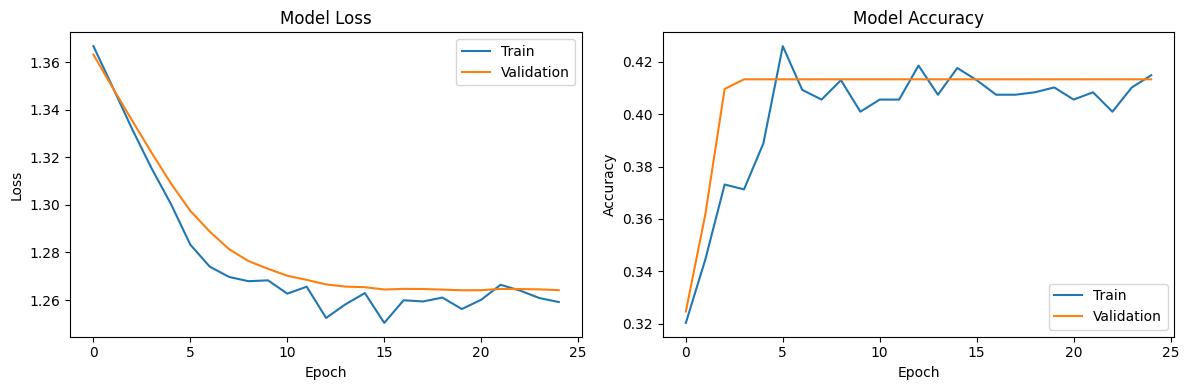

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 4. Model evaluation

Validation Loss: 1.2641
Validation Accuracy: 0.4133
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


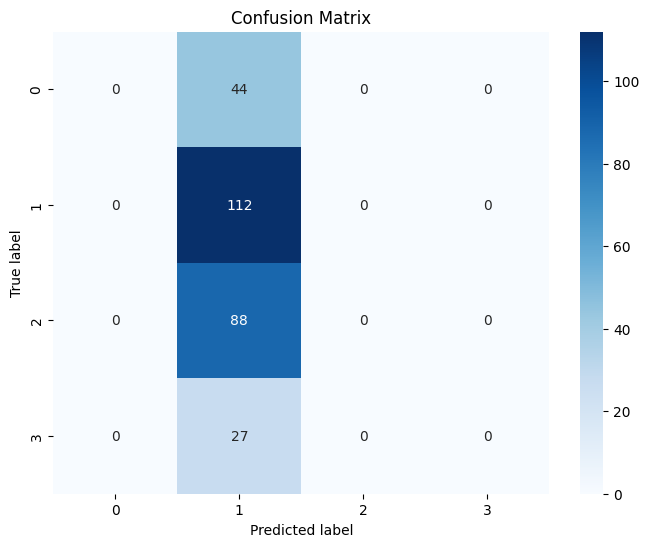

Macro F1 score: 0.1462
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        44
           1       0.41      1.00      0.58       112
           2       0.00      0.00      0.00        88
           3       0.00      0.00      0.00        27

    accuracy                           0.41       271
   macro avg       0.10      0.25      0.15       271
weighted avg       0.17      0.41      0.24       271



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

val_pred_prob = model.predict(X_val)
val_pred = np.argmax(val_pred_prob, axis=1)
val_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

macro_f1 = f1_score(val_true, val_pred, average='macro')
print(f'Macro F1 score: {macro_f1:.4f}')
print(classification_report(val_true, val_pred))